In [ ]:
!pip -q install \
    "pandas==2.2.2" \
    "transformers==4.46.3" \
    "tokenizers==0.20.3" \
    scipy matplotlib tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 92.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 121.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 49.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [ ]:
import gc
import random
import urllib.request

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from transformers import AutoConfig, AutoModel, AutoTokenizer

# set seed for reproducilibity
SEED = 42

MODEL_NAME = "google-bert/bert-base-multilingual-cased"

# BCWS human similarity
SIMILARITY_THRESHOLD = 8.0

# Use at most 600 pairs for a quick run.
# Set to None to use all samples that meet the threshold.
MAX_PAIRS = 600

BATCH_SIZE = 8
MAX_LENGTH = 512

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [ ]:
BCWS_URL = (
    "https://raw.githubusercontent.com/"
    "MiuLab/BCWS/master/bcws.txt"
)

BCWS_PATH = "bcws.txt"

urllib.request.urlretrieve(
    BCWS_URL,
    BCWS_PATH
)

print("Downloaded:", BCWS_PATH)

Downloaded: bcws.txt


In [ ]:
def parse_marked_sentence(marked_sentence):
    left = marked_sentence.index("<")
    right = marked_sentence.index(">", left + 1)

    target_word = marked_sentence[left + 1:right]

    plain_sentence = (
        marked_sentence[:left]
        + target_word
        + marked_sentence[right + 1:]
    )

    return {
        "sentence": plain_sentence,
        "target": target_word,
        "start": left,
        "end": left + len(target_word),
    }

In [ ]:
def load_bcws(path):
    with open(path, "r", encoding="utf-8") as file:
        lines = [
            line.rstrip("\n")
            for line in file
            if line.strip()
        ]

    records = []

    for index in range(0, len(lines), 4):
        pos_tags = lines[index].strip()
        zh_marked = lines[index + 1].strip()
        en_marked = lines[index + 2].strip()

        scores = [
            float(value)
            for value in lines[index + 3].split()
        ]

        # The last value on the score line is the mean human rating
        average_score = scores[-1]

        zh = parse_marked_sentence(zh_marked)
        en = parse_marked_sentence(en_marked)

        records.append({
            "pos_tags": pos_tags,
            "score": average_score,

            "zh_sentence": zh["sentence"],
            "zh_target": zh["target"],
            "zh_start": zh["start"],
            "zh_end": zh["end"],

            "en_sentence": en["sentence"],
            "en_target": en["target"],
            "en_start": en["start"],
            "en_end": en["end"],
        })

    return pd.DataFrame(records)


bcws_df = load_bcws(BCWS_PATH)

print("Total instances:", len(bcws_df))

display(
    bcws_df[
        [
            "score",
            "zh_target",
            "en_target",
            "zh_sentence",
            "en_sentence",
        ]
    ].head()
)

Total instances: 2091


,score,zh_target,en_target,zh_sentence,en_sentence
0,2.05,reduce,cut,Filtering all of the full-text data first can greatly reduce the time needed for full-text scanning.,The ending cut scene shows the reinforcements ...
1,8.59,reduce,decrease,"Because living conditions have improved, the probability of beriberi has fallen sharply.",Klein has praised the work of the school safet...
2,3.73,reduce,attrition,Everyone knows that any method that raises productivity and lowers costs can bring profit to a business.,"Louis XIV wanted a short defensive war, yet by..."
3,1.74,cut,cut,Pedigree has just air-freighted a batch of goods over from Japan and has finished stocking them in the major stores.,This was only one of five post-1948 WB cartoon...
4,4.88,cut,move,"Following the signs toward Lishan, you reach the junction with township road Zhong 124, where a ""Wuling Farm"" sign is visible; turn right here to enter the farm's main area.","The video is shot on a bluescreen, in which Ka..."


In [ ]:
experiment_df = (
    bcws_df[
        bcws_df["score"] >= SIMILARITY_THRESHOLD
    ]
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)

if MAX_PAIRS is not None:
    experiment_df = (
        experiment_df
        .iloc[:MAX_PAIRS]
        .reset_index(drop=True)
    )

print("Pairs used:", len(experiment_df))
print(
    "Score range:",
    experiment_df["score"].min(),
    "to",
    experiment_df["score"].max()
)

display(
    experiment_df[
        [
            "score",
            "zh_target",
            "en_target",
            "zh_sentence",
            "en_sentence",
        ]
    ].head(10)
)

Pairs used: 306
Score range: 8.0 to 10.0


,score,zh_target,en_target,zh_sentence,en_sentence
0,9.45,experience,experience,Mr. Xiao strongly encouraged the author to write up his experience so that everyone could share it.,Habitual residence is less demanding than domi...
1,8.83,increase,increasing,"The new club office on the third floor now houses eight clubs and is expected to add more, so how to allocate club space in the future is naturally a sensitive issue.","However, under braking for turn 1, Räikkönen's..."
2,8.36,emperor,emperor,"The May Fourth Movement, which broke out on May 4, 1919, was a great anti-imperialist and anti-feudal movement.","Diocletian, acclaimed emperor on November 20, ..."
3,8.91,finance,finance,"Professor Hua Mingshu of the Graduate Institute of Finance at Tamkang University published a paper titled ""Speculative Attacks on Foreign Exchange and Exchange Rate Volatility.""",Violations of the campaign finance law could r...
4,9.68,pollution,pollution,"Perhaps ten years from now Taiwan's cities will still be chaotic, with traffic and pollution as bad as ever.",Land pollution can be oil spills caused by oil...
5,8.47,room,room,"As long as you understand plants better and know how to prevent problems and handle them properly, the whole room can be fragrant and green and perfectly safe.",This produces the same result as using a dehum...
6,9.45,wood,wood,"It should meet the five conditions of light, loose, crisp, smooth, and straight, so that the sound has little noise and good resonance. As for the material there is no restriction; the older ...","The oldest working telephone booth in Oregon, ..."
7,9.23,believe,believe,The reason he opposes repetition is that he does not believe at all that art has any value or meaning.,While the authors admit they don't know the fu...
8,9.36,road,roads,"Hsinchu City has quite a few irrigation channels, six major systems in all; among them the Dongda main drainage channel passes major roads in the city and, besides irrigation, currently ...",The New York alignment has remained virtually ...
9,8.85,symbol,symbol,"1. In this parade, the female models used their own nudity as a symbol of protest to spread their message. Punctuation marks, phonetic symbols.",The King’s Table was a carved stone table that...


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=True
)

print("Tokenizer loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded


In [ ]:
@torch.inference_mode()
def extract_target_embeddings(
    dataframe,
    language,
    model,
    tokenizer,
    batch_size=8,
    max_length=512,
):
    if language == "en":
        sentence_column = "en_sentence"
        start_column = "en_start"
        end_column = "en_end"

    elif language == "zh":
        sentence_column = "zh_sentence"
        start_column = "zh_start"
        end_column = "zh_end"

    else:
        raise ValueError("language must be 'en' or 'zh'")

    sentences = dataframe[sentence_column].tolist()
    target_starts = dataframe[start_column].tolist()
    target_ends = dataframe[end_column].tolist()

    all_target_vectors = []

    for batch_start in tqdm(
        range(0, len(sentences), batch_size),
        desc=f"Encoding {language}",
    ):
        batch_end = batch_start + batch_size

        batch_sentences = sentences[
            batch_start:batch_end
        ]

        batch_target_starts = target_starts[
            batch_start:batch_end
        ]

        batch_target_ends = target_ends[
            batch_start:batch_end
        ]

        encoded = tokenizer(
            batch_sentences,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_offsets_mapping=True,
            return_tensors="pt",
        )

        # offset_mapping records the character span in the original sentence for each token
        offset_mapping = (
            encoded
            .pop("offset_mapping")
            .cpu()
            .numpy()
        )

        model_inputs = {
            key: value.to(device)
            for key, value in encoded.items()
        }

        outputs = model(
            **model_inputs,
            output_hidden_states=True,
            return_dict=True,
        )

        # Shape: (13, batch, sequence_length, 768)
        hidden_states = torch.stack(
            outputs.hidden_states,
            dim=0,
        )

        for local_index in range(
            len(batch_sentences)
        ):
            target_start = batch_target_starts[
                local_index
            ]

            target_end = batch_target_ends[
                local_index
            ]

            token_starts = offset_mapping[
                local_index, :, 0
            ]

            token_ends = offset_mapping[
                local_index, :, 1
            ]

            # Find the tokens whose character span overlaps the target word
            target_token_positions = np.where(
                (token_ends > target_start)
                & (token_starts < target_end)
            )[0]

            if len(target_token_positions) == 0:
                raise RuntimeError(
                    "Target token not found:\n"
                    + batch_sentences[local_index]
                )

            positions_tensor = torch.as_tensor(
                target_token_positions,
                device=device,
            )

            # Average over multiple WordPieces
            # Output shape: (13, 768)
            target_vector = (
                hidden_states[
                    :,
                    local_index,
                    positions_tensor,
                    :,
                ]
                .mean(dim=1)
            )

            all_target_vectors.append(
                target_vector
                .float()
                .cpu()
                .numpy()
            )

        del outputs
        del hidden_states

    return np.stack(
        all_target_vectors,
        axis=0,
    )

In [ ]:
pretrained_model = AutoModel.from_pretrained(
    MODEL_NAME
).to(device)

pretrained_model.eval()

print("Pretrained mBERT loaded")

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Pretrained mBERT loaded


In [ ]:
pretrained_en = extract_target_embeddings(
    dataframe=experiment_df,
    language="en",
    model=pretrained_model,
    tokenizer=tokenizer,
    batch_size=BATCH_SIZE,
    max_length=MAX_LENGTH,
)

print("Pretrained English:", pretrained_en.shape)

Encoding en:   0%|          | 0/39 [00:00<?, ?it/s]

Pretrained English: (306, 13, 768)


In [ ]:
pretrained_zh = extract_target_embeddings(
    dataframe=experiment_df,
    language="zh",
    model=pretrained_model,
    tokenizer=tokenizer,
    batch_size=BATCH_SIZE,
    max_length=MAX_LENGTH,
)

print("Pretrained Chinese:", pretrained_zh.shape)

Encoding zh:   0%|          | 0/39 [00:00<?, ?it/s]

Pretrained Chinese: (306, 13, 768)


In [ ]:
del pretrained_model

gc.collect()
torch.cuda.empty_cache()

In [ ]:
torch.manual_seed(123)
torch.cuda.manual_seed_all(123)

random_config_en = AutoConfig.from_pretrained(
    MODEL_NAME
)

random_model_en = AutoModel.from_config(
    random_config_en
).to(device)

random_model_en.eval()

random_en = extract_target_embeddings(
    dataframe=experiment_df,
    language="en",
    model=random_model_en,
    tokenizer=tokenizer,
    batch_size=BATCH_SIZE,
    max_length=MAX_LENGTH,
)

print("Random English:", random_en.shape)

del random_model_en

gc.collect()
torch.cuda.empty_cache()

Encoding en:   0%|          | 0/39 [00:00<?, ?it/s]

Random English: (306, 13, 768)


In [ ]:
torch.manual_seed(456)
torch.cuda.manual_seed_all(456)

random_config_zh = AutoConfig.from_pretrained(
    MODEL_NAME
)

random_model_zh = AutoModel.from_config(
    random_config_zh
).to(device)

random_model_zh.eval()

random_zh = extract_target_embeddings(
    dataframe=experiment_df,
    language="zh",
    model=random_model_zh,
    tokenizer=tokenizer,
    batch_size=BATCH_SIZE,
    max_length=MAX_LENGTH,
)

print("Random Chinese:", random_zh.shape)

del random_model_zh

gc.collect()
torch.cuda.empty_cache()

Encoding zh:   0%|          | 0/39 [00:00<?, ?it/s]

Random Chinese: (306, 13, 768)


In [ ]:
def pearson_per_pair(
    english_vectors,
    chinese_vectors,
):
    """
    Input shape:
        (pairs, 13, 768)

    Output shape:
        (pairs, 13)
    """

    en_zero_mean = (
        english_vectors
        - english_vectors.mean(
            axis=-1,
            keepdims=True,
        )
    )

    zh_zero_mean = (
        chinese_vectors
        - chinese_vectors.mean(
            axis=-1,
            keepdims=True,
        )
    )

    numerator = (
        en_zero_mean
        * zh_zero_mean
    ).sum(axis=-1)

    denominator = np.sqrt(
        (
            en_zero_mean ** 2
        ).sum(axis=-1)
        *
        (
            zh_zero_mean ** 2
        ).sum(axis=-1)
    )

    return numerator / np.clip(
        denominator,
        1e-12,
        None,
    )

In [ ]:
pretrained_correlations = pearson_per_pair(
    pretrained_en,
    pretrained_zh,
)

random_correlations = pearson_per_pair(
    random_en,
    random_zh,
)

print(
    "Pretrained correlations:",
    pretrained_correlations.shape
)

print(
    "Random correlations:",
    random_correlations.shape
)

Pretrained correlations: (306, 13)
Random correlations: (306, 13)


In [ ]:
def mean_and_sem(correlations):
    mean_values = correlations.mean(axis=0)

    sem_values = (
        correlations.std(axis=0, ddof=1)
        / np.sqrt(correlations.shape[0])
    )

    return mean_values, sem_values


pretrained_mean, pretrained_sem = mean_and_sem(
    pretrained_correlations
)

random_mean, random_sem = mean_and_sem(
    random_correlations
)

In [ ]:
layer_results = pd.DataFrame({
    "Layer": np.arange(13),
    "Pretrained mBERT": pretrained_mean,
    "Pretrained SEM": pretrained_sem,
    "Independent random baseline": random_mean,
    "Random SEM": random_sem,
})

display(
    layer_results.round(4)
)

,Layer,Pretrained mBERT,Pretrained SEM,Independent random baseline,Random SEM
0,0,0.1743,0.0062,0.0029,0.0018
1,1,0.2783,0.0057,0.0117,0.0018
2,2,0.3263,0.0054,0.0164,0.0018
3,3,0.4511,0.0047,0.0073,0.0018
4,4,0.5399,0.0042,0.0032,0.0016
5,5,0.6319,0.0037,-0.0146,0.0016
6,6,0.6840,0.0034,-0.0005,0.0015
7,7,0.6010,0.0041,0.0006,0.0016
8,8,0.5784,0.0042,-0.0073,0.0015
9,9,0.6564,0.0037,-0.0197,0.0016


In [ ]:
best_layer = int(
    np.argmax(pretrained_mean)
)

print("Best layer:", best_layer)
print(
    "Pretrained mean r:",
    round(
        pretrained_mean[best_layer],
        4,
    )
)

print(
    "Random baseline r:",
    round(
        random_mean[best_layer],
        4,
    )
)

Best layer: 10
Pretrained mean r: 0.7087
Random baseline r: -0.0088


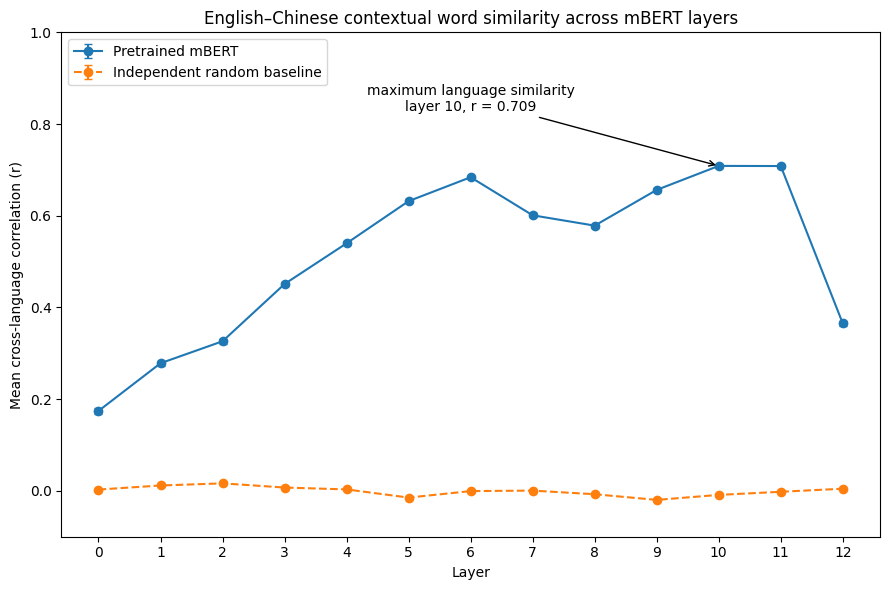

In [ ]:
layers = np.arange(13)

best_layer = int(
    np.argmax(pretrained_mean)
)

plt.figure(figsize=(9, 6))

plt.errorbar(
    layers,
    pretrained_mean,
    yerr=pretrained_sem,
    marker="o",
    capsize=3,
    label="Pretrained mBERT",
)

plt.errorbar(
    layers,
    random_mean,
    yerr=random_sem,
    marker="o",
    linestyle="--",
    capsize=3,
    label="Independent random baseline",
)

plt.annotate(
    (
        "maximum language similarity\n"
        f"layer {best_layer}, "
        f"r = {pretrained_mean[best_layer]:.3f}"
    ),
    xy=(
        best_layer,
        pretrained_mean[best_layer],
    ),
    xytext=(
        max(1, best_layer - 4),
        min(
            0.95,
            pretrained_mean[best_layer] + 0.12,
        ),
    ),
    arrowprops={
        "arrowstyle": "->",
    },
    ha="center",
)

plt.xlabel("Layer")

plt.ylabel(
    "Mean cross-language correlation (r)"
)

plt.title(
    "English–Chinese contextual word similarity "
    "across mBERT layers"
)

plt.xticks(layers)
plt.ylim(-0.1, 1.0)
plt.legend()
plt.tight_layout()

plt.savefig(
    "bcws_mbert_layer_similarity.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

In [ ]:
inspection_df = experiment_df[
    [
        "score",
        "zh_target",
        "en_target",
        "zh_sentence",
        "en_sentence",
    ]
].copy()

inspection_df[
    "mBERT correlation"
] = pretrained_correlations[
    :,
    best_layer,
]

In [ ]:
display(
    inspection_df
    .sort_values(
        "mBERT correlation",
        ascending=False,
    )
    .head(20)
)

,score,zh_target,en_target,zh_sentence,en_sentence,mBERT correlation
48,9.06,army,military,"At that time the enemy from the north invaded, and all men of eligible age across the country had to be enlisted into the army to fight.",A 2006 Sun-Times article reports that gangs en...,0.852500
304,8.50,disappear,vanish,The oversupply in the global oil market will take a long time to disappear.,"In 1612, the plane of the rings was oriented d...",0.832578
252,8.07,taoism,taoist,"There are some local folk religions that blend Buddhism, Taoism, and Confucian thought, because they best fit the needs and ideas of local residents.",The central text of Taoism and taoist philosop...,0.831704
77,9.48,court,courthouse,"Many law firms are concentrated near the court, and clients also expect to look for such services in these areas.",The resulting fire destroyed the bell tower of...,0.830966
4,9.68,pollution,pollution,"Perhaps ten years from now Taiwan's cities will still be chaotic, with traffic and pollution as bad as ever.",Land pollution can be oil spills caused by oil...,0.816225
228,8.85,city,urban,"Many undomesticated wild animals, whether because they are large and fierce, or because there is no husbandry information available or they simply cannot be tamed, kept in cities and ...","This was, in many ways, a forerunner to the bi...",0.814124
157,9.27,believe,believe,"Because the bottom quark had already been discovered, physicists believe that its partner, the top quark, should also exist.",Some Manx people believe the name was derived ...,0.813086
179,8.76,surgery,surgical,"The company also uses refined techniques to produce a batch of high-performance surgical medicines, paired with elegant health kits, distributed on consignment directly into every ... remote area.",He developed new surgical techniques in 1924 f...,0.812832
296,9.14,military,military,"During the martial law period, non-active-duty personnel subjected to military judgment may petition for retrial and extraordinary appeal.","He was said to have been modest, no doubt a re...",0.812598
104,8.68,coral,coral,"This exhibition hall, run by the Dadongshan Jewelry Group, offers display areas for valuable coral, aragonite, colored glaze, and more.",Other notable structures from the period inclu...,0.811442


In [ ]:
display(
    inspection_df
    .sort_values(
        "mBERT correlation",
        ascending=True,
    )
    .head(20)
)

,score,zh_target,en_target,zh_sentence,en_sentence,mBERT correlation
71,10.00,husband,husband,A husband should take care of his wife and infant and show mutual understanding.,There were 723 households out of which 28.6% h...,0.405839
33,8.86,year,year,"An astronomy lecture, in an accessible way, introduces children and parents to various methods of timekeeping and explains year, month, day, hour, ...",The game was a rematch of the previous year's ...,0.514164
161,9.95,tropical,tropical,"The sea in this area is calm and waveless, free all year from typhoons or earthquakes, and the tropical heat is much softened by the cool ocean breeze.",Its natural habitats are subtropical or tropic...,0.545217
27,8.88,able,able,"Without a proper way to make members understand how to actually perform, a barrier naturally arises. Conversely, if a two-way channel of communication can be established, then ...",Parsons used his income from gambling which he...,0.560092
217,8.75,compose,constitute,"Singapore is a multiethnic country, composed of Chinese, Malays, and Indians. Because of this, the country is divided into four cultural zones, namely the colonial ...","Of the total population, males constitute abou...",0.561722
238,8.23,fact,fact,"Because he refused to accept the facts and could not solve the problem, neither his mind nor his experience grew.",Proponents of Lenin's position on the national...,0.565292
55,8.18,right,right,"Going to school every day is like practicing martial arts: watch in all directions and see clearly; dodging left and right is hard, but caution is a blessing.",Ford of Brazil produces a pick-up truck versio...,0.570024
150,9.85,nine,nine,"Taichung City is one of the most competitive areas, with nine cable systems applying for operating licenses, four of which produce their own news programs.",It's ten to nine.,0.573310
95,8.40,short,short,"Located northeast of the main island of Athens, the trip is not as far as to the other islands, making it the best choice for young people on a budget and for short trips!","After the death of Mendelssohn, Dubno stopped ...",0.575720
47,8.98,tea,tea,"For people who tend to be tense or under heavy work pressure, drinking more lotus-root tea, or lotus-root and pork-rib soup, can help ease stress and relieve fatigue, ...",The high value which was set on the Barbara Gi...,0.577896


In [ ]:
layer_results.to_csv(
    "bcws_mbert_layer_results.csv",
    index=False,
)

inspection_df.to_csv(
    "bcws_target_word_results.csv",
    index=False,
)

print("Saved files:")
print("bcws_mbert_layer_results.csv")
print("bcws_target_word_results.csv")
print("bcws_mbert_layer_similarity.png")

Saved files:
bcws_mbert_layer_results.csv
bcws_target_word_results.csv
bcws_mbert_layer_similarity.png
